# Environment Setup

## PIP

In [18]:
!pip install colour
!pip install matplotlib
!pip install pandas
!pip install utm


## Imports

In [19]:

import math
import matplotlib.pyplot as plt
import matplotlib_inline
import numpy as np
import pandas as pd
import utm
from itertools import product
from collections import defaultdict
import io
import pandas as pd
import pickle
import matplotlib.patches as patches
import glob
import os
import datetime



## Functions

In [95]:
def windAnalysis(heading,windDirection, windSpeed):
    newWindDirections = []
    newWindSpeeds = []
    for i in range(0,windDirection.__len__()):
        if(windDirection[i] == 'nan' or heading[i] == 'NaN'):
            a = 1 
        elif(float(windDirection[i]) < 0):
            windScaled = 360+float(windDirection[i])
            windMagnetic = windScaled + float(heading[i])
            if(windMagnetic >= 360):
                windMagnetic = windMagnetic - 360
            newWindDirections.append(float(windMagnetic))
        elif(float(windDirection[i]) > 0):
            windMagnetic = float(windDirection[i]) +float(heading[i])
            if(windMagnetic >= 360):
                windMagnetic = windMagnetic - 360
            newWindDirections.append(float(windMagnetic))

    for i in range(0,windSpeed.__len__()):
        if(windSpeed[i] == 'nan'):
            a = 1 
        elif(float(windSpeed[i]) < 0):
            newWindSpeeds.append(float(windSpeed[i]))
        elif(float(windSpeed[i]) > 0):
            newWindSpeeds.append(float(windSpeed[i]))
        

    ## Calculate Average Wind Direction and Speed and put in a bin
    totalDirection = 0
    totalSpeed = 0
    for i in range(0,newWindDirections.__len__()):
        totalDirection += newWindDirections[i]

    for i in range(0,newWindSpeeds.__len__()):
        totalSpeed += float(newWindSpeeds[i])


    avgDirection = totalDirection/newWindDirections.__len__() 
    avgSpeed = totalSpeed/newWindSpeeds.__len__()
    if math.isnan(avgDirection):
        avgDirection = 0
    return [avgDirection,avgSpeed]

def windBins(dfArray):
    directionBins = [[] for _ in range(361)]
    speedBins = [[] for _ in range(50)]
    for i in range(0,90):
        currdf = dfArray[i]
        if (' WndDr' in currdf) and (' WndSpd' in currdf) and (' HDG' in currdf):
            averages = windAnalysis(currdf[' HDG'],currdf[' WndDr'],currdf[' WndSpd'])
            destinationBin = int(math.floor(averages[0]))
            speedBin = int(math.floor(averages[1]))
            # print(math.floor(averages[0]))
            # print(destinationBin, "--" , i,"speed",speedBin )
            directionBins[destinationBin].append(i)
            speedBins[speedBin].append(i)
    return (directionBins,speedBins)




def summaryStatistics(descent,summaryTarget:str,file,currFlight,descentNum):
    meanDescentRate = np.mean(pd.to_numeric(descent[summaryTarget]))
    medianDescentRate = np.median(pd.to_numeric(descent[summaryTarget]))
    stdDescentRate = np.std(pd.to_numeric(descent[summaryTarget]))
    maxDescentRate = np.max(pd.to_numeric(descent[summaryTarget]))
    minDescentRate = np.min(pd.to_numeric(descent[summaryTarget]))
    results = (float(meanDescentRate), float(medianDescentRate), float(stdDescentRate), float(maxDescentRate), float(minDescentRate))
    file.write("{}, {}, {},{},{},{},{}\n".format(currFlight,descentNum,results[0],results[1],results[2],results[3],results[4]))
    file.flush()


## Global Variables

In [ ]:
directionBins = [[] for _ in range(361)]
speedBins = [[] for _ in range(50)]
colors =["red","green","blue","purple","orange","black","yellow","cyan","magenta","brown","pink","gray","olive","lime","teal","navy"]


# Data Ingestion

In [22]:
aircraft = "Cessna_172S_flight_"
dfArray = []
for x in range(1,101):
    new_df = pd.read_csv(f'../../Project_Data/Empirical_Data/GATS_Dataset/{aircraft}{x}.csv')
    dfArray.append(new_df)

# df = pd.read_csv(f'../../Project_Data/Empirical_Data/GATS_Dataset/{aircraft}1.csv')
# df2 = pd.read_csv(f'../../Project_Data/Empirical_Data/GATS_Dataset/{aircraft}2574.csv')
dfArray[0].head()
dfArray.__len__()

100

# Populate Descents

In [97]:
descentArray = [[] for _ in range(0,dfArray.__len__())]
headingAtLanding = []
fieldElevation = []
magneticVariation = []
crossWindComponent = []
minStep = 50
maxStep = 500
excludedDescents = []

files = glob.glob('../Figures/Empirical/Summary_Statistics/*')
for f in files:
    os.remove(f)

timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
filePitch = open("../Figures/Empirical/Summary_Statistics/pitch_summary_{}".format(timestamp),"w")
fileRoll = open("../Figures/Empirical/Summary_Statistics/roll_summary_{}".format(timestamp),"w")
fileCAS = open("../Figures/Empirical/Summary_Statistics/cas_summary_{}".format(timestamp),"w")
fileIAS = open("../Figures/Empirical/Summary_Statistics/ias_summary_{}".format(timestamp),"w")
fileVspd = open("../Figures/Empirical/Summary_Statistics/vspd_summary_{}".format(timestamp),"w")
for file in [filePitch,fileRoll,fileVspd,fileCAS,fileIAS]:
    file.close()

filePitch = open("../Figures/Empirical/Summary_Statistics/pitch_summary_{}".format(timestamp),"a")
fileRoll = open("../Figures/Empirical/Summary_Statistics/roll_summary_{}".format(timestamp),"a")
fileCAS = open("../Figures/Empirical/Summary_Statistics/cas_summary_{}".format(timestamp),"a")
fileIAS = open("../Figures/Empirical/Summary_Statistics/ias_summary_{}".format(timestamp),"a")
fileVspd = open("../Figures/Empirical/Summary_Statistics/vspd_summary_{}".format(timestamp),"a")

for file in [filePitch,fileRoll,fileVspd,fileCAS,fileIAS]:
    file.write("Flight#, Descent#, Mean, Median, StdDev, Max, Min\n")
file.flush()

def checkExcluded(x1,x2,excludedDescents):
    for descent in excludedDescents:
        if(x1>= descent[0] and x1 <= descent[1] 
           or
           x2>= descent[0] and x2 <= descent[1]
           or descent[0]>= x1 and descent[0] <= x2 and descent[1]>= x1 and descent[1] <= x2):
            return True
    return False

for x in range (0,90):
    currdf = dfArray[x]
    excludedDescents = []
    # x1 = 0
    # x2 = 50


    for stepCount in range(minStep,maxStep):
        step = stepCount
        altitudeDeltaThreshold = 800

        for xInner in range(0, currdf.__len__()-step, step):
            storageCount = 0
            x1 = xInner
            x2 = xInner+step
            delta = currdf['AltAGL'][x1] - currdf['AltAGL'][x2]
            if delta >= altitudeDeltaThreshold and currdf['AltAGL'][x2] <= 0 and currdf['AltAGL'][x1] > 0.0:
                # print(f"Found Descent in flight {x}: From {currdf['AltAGL'][x1]} ft AGL to {currdf['AltAGL'][x2]} ft AGL over {x2-x1} data points.")
                if(currdf['AltAGL'][x1] <= 1020 and currdf['AltAGL'][x1] >=1000):
                    # print(f"Found Descent in flight {x}: From {currdf['AltAGL'][x1]} ft AGL to {currdf['AltAGL'][x2]} ft AGL over {x2-x1} data points.")
                    excludeDescent = checkExcluded(x1,x2,excludedDescents)
                    if(excludeDescent):                
                        ## Do Nothing 
                        print("descent excluded: {} to {} in flight {}".format(x1,x2,x))
                    elif(not excludeDescent):
                        newDataFrame = pd.DataFrame(currdf[:][x1:x2]).reset_index()
                        descentArray[x].append(newDataFrame)
                        headingAtLanding.append(currdf[' HDG'][x2]) #Heading at Landing
                        fieldElevation.append(currdf[' AltMSL'][x2]) #Field Elevation at Landing
                        magneticVariation.append(currdf[' MagVar'][x2])
                        excludedDescents.append([x1,x2])
                        currFlight = x 

                        summaryStatistics(newDataFrame,' Pitch',filePitch,currFlight,excludedDescents.__len__())
                        summaryStatistics(newDataFrame,' Roll',fileRoll,currFlight,excludedDescents.__len__())
                        summaryStatistics(newDataFrame,' CAS',fileCAS,currFlight,excludedDescents.__len__())
                        summaryStatistics(newDataFrame,' IAS',fileIAS,currFlight,excludedDescents.__len__())
                        summaryStatistics(newDataFrame,' VSpd',fileVspd,currFlight,excludedDescents.__len__())
                        print("Descent added to exclusion between: {} to {} in flight {}".format(x1,x2,x))
                        
                    ##Clearning Descent from array

                    # for i in range(x1,x2+1):
                    #     currdf['AltAGL'][i] = 0

                    # crossWindComponent.append(currdf[' WndSpd'][x2] * math.sin(currdf[' HDG'][x2]-currdf[' WndDr'][x2])) #Crosswind Component at Landing
                    storageCount+=1


        
        # descentArray[0].head()
        # x1 = xInner
        # x2 = xInner+step

descentArray.__len__()

Descent added to exclusion between: 3738 to 4005 in flight 0
Descent added to exclusion between: 2037 to 2328 in flight 0
Descent added to exclusion between: 3640 to 4004 in flight 1
Descent added to exclusion between: 4032 to 4368 in flight 2
Descent added to exclusion between: 4296 to 4654 in flight 4
Descent added to exclusion between: 2484 to 2760 in flight 6
descent excluded: 2485 to 2840 in flight 6
descent excluded: 2484 to 2898 in flight 6
Descent added to exclusion between: 5292 to 5544 in flight 7
descent excluded: 5292 to 5586 in flight 7
descent excluded: 5296 to 5627 in flight 7
descent excluded: 5295 to 5648 in flight 7
descent excluded: 5292 to 5670 in flight 7
Descent added to exclusion between: 4708 to 4922 in flight 8
Descent added to exclusion between: 4371 to 4512 in flight 9
descent excluded: 4370 to 4560 in flight 9
Descent added to exclusion between: 4176 to 4524 in flight 11
Descent added to exclusion between: 4556 to 4824 in flight 12
Descent added to exclusion

100

# Wind Direction Batch

In [43]:
bins = windBins(dfArray)
directionBins = bins[0]
speedBins = bins[1]

TypeError: summaryStatistics() missing 1 required positional argument: 'descentNum'

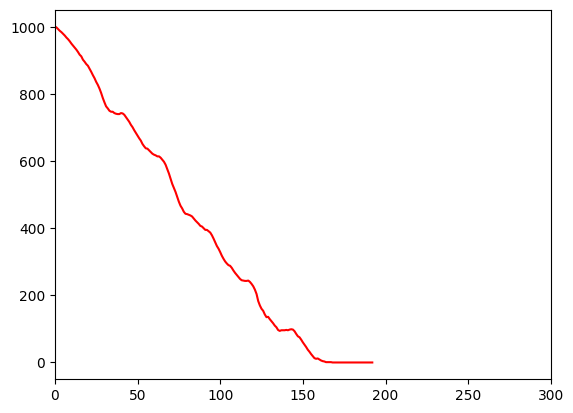

In [88]:
files = glob.glob('../Figures/Empirical/Wind_Direction_Batch/*')
for f in files:
    os.remove(f)
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

files = glob.glob('../Figures/Empirical/Summary_Statistics/summary_wind_direction_*')
for f in files:
    os.remove(f)
file = open("../Figures/Empirical/Summary_Statistics/summary_wind_direction_{}".format(timestamp),"w")
file.close()
file = open("../Figures/Empirical/Summary_Statistics/summary_wind_direction_{}".format(timestamp),"a")
file.write("Flight#, Descent#, Mean, Median, StdDev, Max, Min\n")
file.flush()
# axes = descentArray[0]['AltAGL'].plot(kind='line', title='Altitude AGL Distribution',figsize=(15,3))
# descentArray[0][' HDG'].plot(ax=axes, kind='line')
# descentArray[0][' Roll'].plot(ax=axes, kind='line',secondary_y=True)
# descentArray[0][' Pitch'].plot(ax=axes, kind='line',secondary_y=True)
headingTolerance = 10
elevationTolerance = 2
magneticVariationTolerance = 1
minimumRunwayLength = 0
# print("Heading:",headingAtLanding[0],"----", "Elevation:",fieldElevation[0],"----", "Magnetic Variation:",magneticVariation[0])
# print(findRunway(headingAtLanding[0],fieldElevation[0],magneticVariation[0],headingTolerance,elevationTolerance,magneticVariationTolerance,minimumRunwayLength))

# descentArray[0][' GndSpd'].plot(ax=axes, kind='line', title='Altitude AGL Distribution',figsize=(15,3),secondary_y=True)
# axes = descentArray[0][' COM1'].plot( kind='hist', secondary_y=True)


for x in range(0,directionBins.__len__()):
    numOfLandingsPlotted = 0
    for y in range(0,directionBins[x].__len__()):
        currFlight = directionBins[x][y]
        for descent in range(0,descentArray[currFlight].__len__()):
            plt.xlim(0,300)
            descentArray[currFlight][descent]['AltAGL'].plot( kind='line',color=(colors[y] if colors[y] else "black"))
            numOfLandingsPlotted+=1
            summaryStatistics(descentArray[currFlight][descent],file,currFlight,descent)
            # descentArray[x][' HDG'].plot(ax=axes, kind='line',secondary_y=True)
            # print("Heading:",headingAtLanding[x],"----", "Elevation:",fieldElevation[x],"----", "Magnetic Variation:",magneticVariation[x])
            # print(findRunway(headingAtLanding[x],fieldElevation[x],magneticVariation[x],headingTolerance,elevationTolerance,magneticVariationTolerance,minimumRunwayLength))
            plt.title("Wind Direction: {}, Flights: {}, Landings:{} ".format(x,directionBins[x],numOfLandingsPlotted)) 
            plt.savefig("../Figures/Empirical/Wind_Direction_Batch/WindDirection_{}_Empirical_Analysis_{}.png".format(x,timestamp))
            plt.clf()
    # plt.show()


# Wind Speed Batch

In [48]:
bins = windBins(dfArray)
directionBins = bins[0]
speedBins = bins[1]

In [ ]:
files = glob.glob('../Figures/Empirical/Wind_Speed_Batch/*')
for f in files:
    os.remove(f)
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# files = glob.glob('../Figures/Empirical/Summary_Statistics/*')
# for f in files:
#     os.remove(f)

# filePitch = open("../Figures/Empirical/Summary_Statistics/pitch_summary_wind_speed_{}".format(timestamp),"w")
# fileRoll = open("../Figures/Empirical/Summary_Statistics/roll_summary_wind_speed_{}".format(timestamp),"w")
# fileCAS = open("../Figures/Empirical/Summary_Statistics/cas_summary_wind_speed_{}".format(timestamp),"w")
# fileIAS = open("../Figures/Empirical/Summary_Statistics/ias_summary_wind_speed_{}".format(timestamp),"w")
# fileVspd = open("../Figures/Empirical/Summary_Statistics/vspd_summary_wind_speed_{}".format(timestamp),"w")
# file.close()
# filePitch = open("../Figures/Empirical/Summary_Statistics/pitch_summary_wind_speed_{}".format(timestamp),"a")
# fileRoll = open("../Figures/Empirical/Summary_Statistics/roll_summary_wind_speed_{}".format(timestamp),"a")
# fileCAS = open("../Figures/Empirical/Summary_Statistics/cas_summary_wind_speed_{}".format(timestamp),"a")
# fileIAS = open("../Figures/Empirical/Summary_Statistics/ias_summary_wind_speed_{}".format(timestamp),"a")
# fileVspd = open("../Figures/Empirical/Summary_Statistics/vspd_summary_wind_speed_{}".format(timestamp),"a")

# for file in [filePitch,fileRoll,fileVspd,fileCAS,fileIAS]:
#     file.write("Flight#, Descent#, Mean, Median, StdDev, Max, Min\n")
# file.flush()
for x in range(0,speedBins.__len__()):
    numOfLandingsPlotted2 = 0
    for y in range(0,speedBins[x].__len__()):
        currFlight = speedBins[x][y]
        for descent in range(0,descentArray[currFlight].__len__()):
            plt.xlim(0,300)
            descentArray[currFlight][descent]['AltAGL'].plot( kind='line',color=(colors[y] if colors[y] else "black"))
            numOfLandingsPlotted2+=1
            # descentArray[x][' HDG'].plot(ax=axes, kind='line',secondary_y=True)
            # print("Heading:",headingAtLanding[x],"----", "Elevation:",fieldElevation[x],"----", "Magnetic Variation:",magneticVariation[x])
            # print(findRunway(headingAtLanding[x],fieldElevation[x],magneticVariation[x],headingTolerance,elevationTolerance,magneticVariationTolerance,minimumRunwayLength))
            # summaryStatistics(descentArray[currFlight][descent],' Pitch',filePitch,currFlight,descent)
            # summaryStatistics(descentArray[currFlight][descent],' Roll',fileRoll,currFlight,descent)
            # summaryStatistics(descentArray[currFlight][descent],' CAS',fileCAS,currFlight,descent)
            # summaryStatistics(descentArray[currFlight][descent],' IAS',fileIAS,currFlight,descent)
            # summaryStatistics(descentArray[currFlight][descent],' VSpd',fileVspd,currFlight,descent)
            # print("Flight {}, Descent # {}: {}".format(currFlight,descent,results))
            plt.title("Wind Speed: {}, Flights: {}, Landings:{} ".format(x,speedBins[x],numOfLandingsPlotted2))  
            plt.savefig("../Figures/Empirical/Wind_Speed_Batch/WindSpeed_{}_Empirical_Analysis_{}.png".format(x,timestamp))
    plt.clf()

    # plt.show()
file.close()

<Figure size 640x480 with 0 Axes>